## Step 3: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_labeled = pd.read_csv("../data/loan_clean_labeled.csv")
print(df_labeled.shape)          # expect (20000, 28)

# Your column groups (reused in every exercise below)
cat_cols = df_labeled.select_dtypes(exclude="number").columns.tolist()
num_cols = df_labeled.select_dtypes(include="number").columns.tolist()
print("Text columns:", cat_cols)
print("Numeric columns:", len(num_cols))

(20000, 28)
Text columns: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
Numeric columns: 23


#### Shape of the target

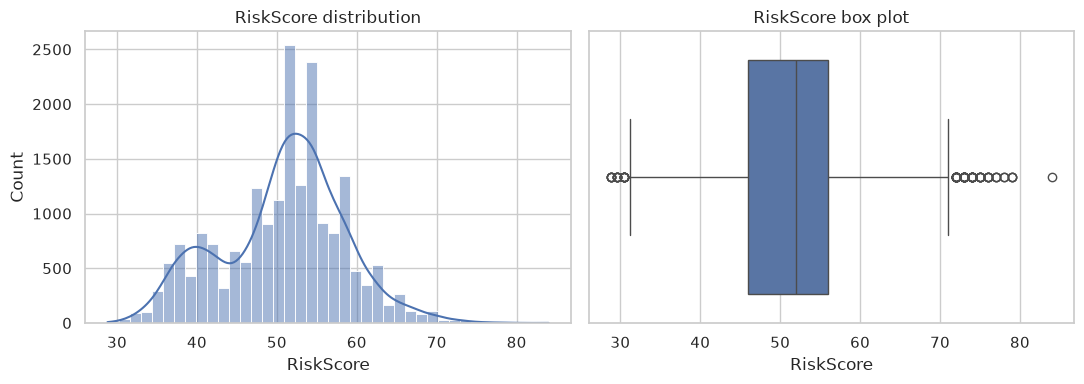

Skew: -0.16


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_labeled["RiskScore"], bins=40, kde=True, ax=ax[0])
sns.boxplot(x=df_labeled["RiskScore"], ax=ax[1])
ax[0].set_title("RiskScore distribution")
ax[1].set_title("RiskScore box plot")
plt.tight_layout(); plt.show()

print("Skew:", round(df_labeled["RiskScore"].skew(), 2))

RiskScore is roughly bell-shaped, centered around 52, with skew of -0.16. This is balanced, so no transform is needed. A smaller bump appears near 40, which may reflect a distinct borrower group. I will look for it in the feature comparisons.

## Numeric features vs. RiskScore

In [3]:
wanted = ["CreditScore", "DebtToIncomeRatio", "AnnualIncome", "LoanAmount"]
plot_cols = [c for c in wanted if c in df_labeled.columns]
print(plot_cols)   # if one is missing, swap in a column name from num_cols

['CreditScore', 'DebtToIncomeRatio', 'AnnualIncome', 'LoanAmount']


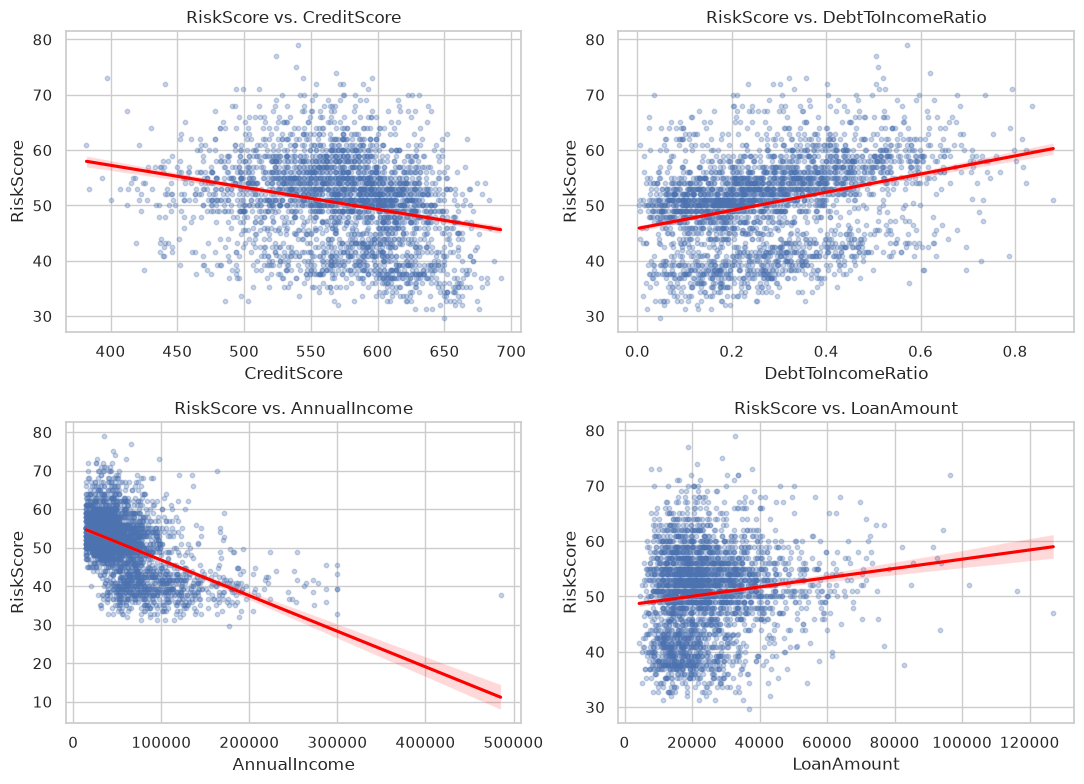

In [4]:
sample = df_labeled.sample(3000, random_state=42)   # 3,000 dots is enough and loads fast

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, c in zip(axes.ravel(), plot_cols):
    sns.regplot(data=sample, x=c, y="RiskScore",
                scatter_kws={"alpha": 0.3, "s": 10},
                line_kws={"color": "red"}, ax=ax)
    ax.set_title(f"RiskScore vs. {c}")
plt.tight_layout(); plt.show()

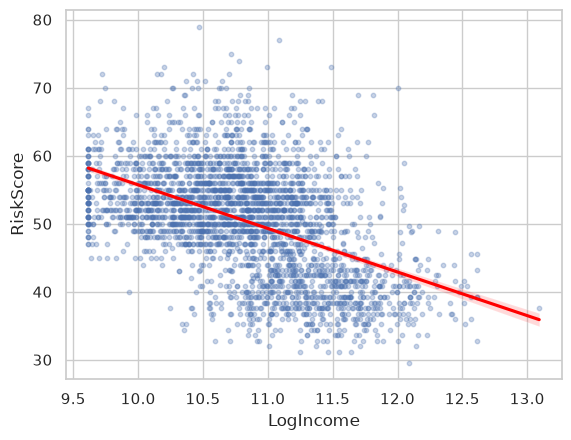

In [5]:
sns.regplot(data=sample.assign(LogIncome=np.log1p(sample["AnnualIncome"])),
            x="LogIncome", y="RiskScore",
            scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
plt.show()

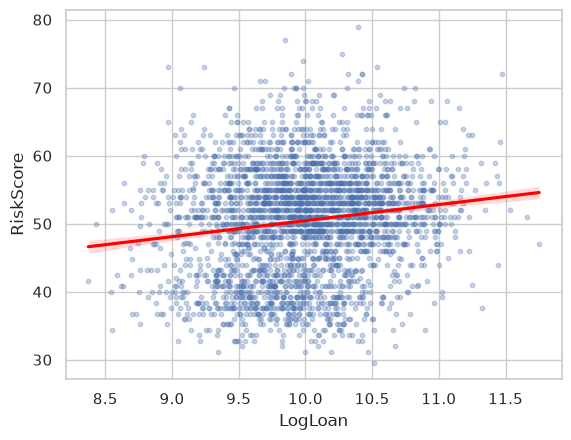

In [6]:
sns.regplot(data=sample.assign(LogLoan=np.log1p(sample["LoanAmount"])),
            x="LogLoan", y="RiskScore",
            scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
plt.show()

In [7]:
log_cols = ["SavingsAccountBalance", "TotalLiabilities", "TotalAssets",
            "CheckingAccountBalance", "AnnualIncome", "LoanAmount"]

pd.DataFrame({
    "before": df_labeled[log_cols].skew(),
    "after":  np.log1p(df_labeled[log_cols]).skew()
}).round(2)

,before,after
SavingsAccountBalance,6.06,-0.01
TotalLiabilities,5.85,-0.01
TotalAssets,5.31,0.04
CheckingAccountBalance,4.75,-0.04
AnnualIncome,2.09,0.16
LoanAmount,1.83,0.02


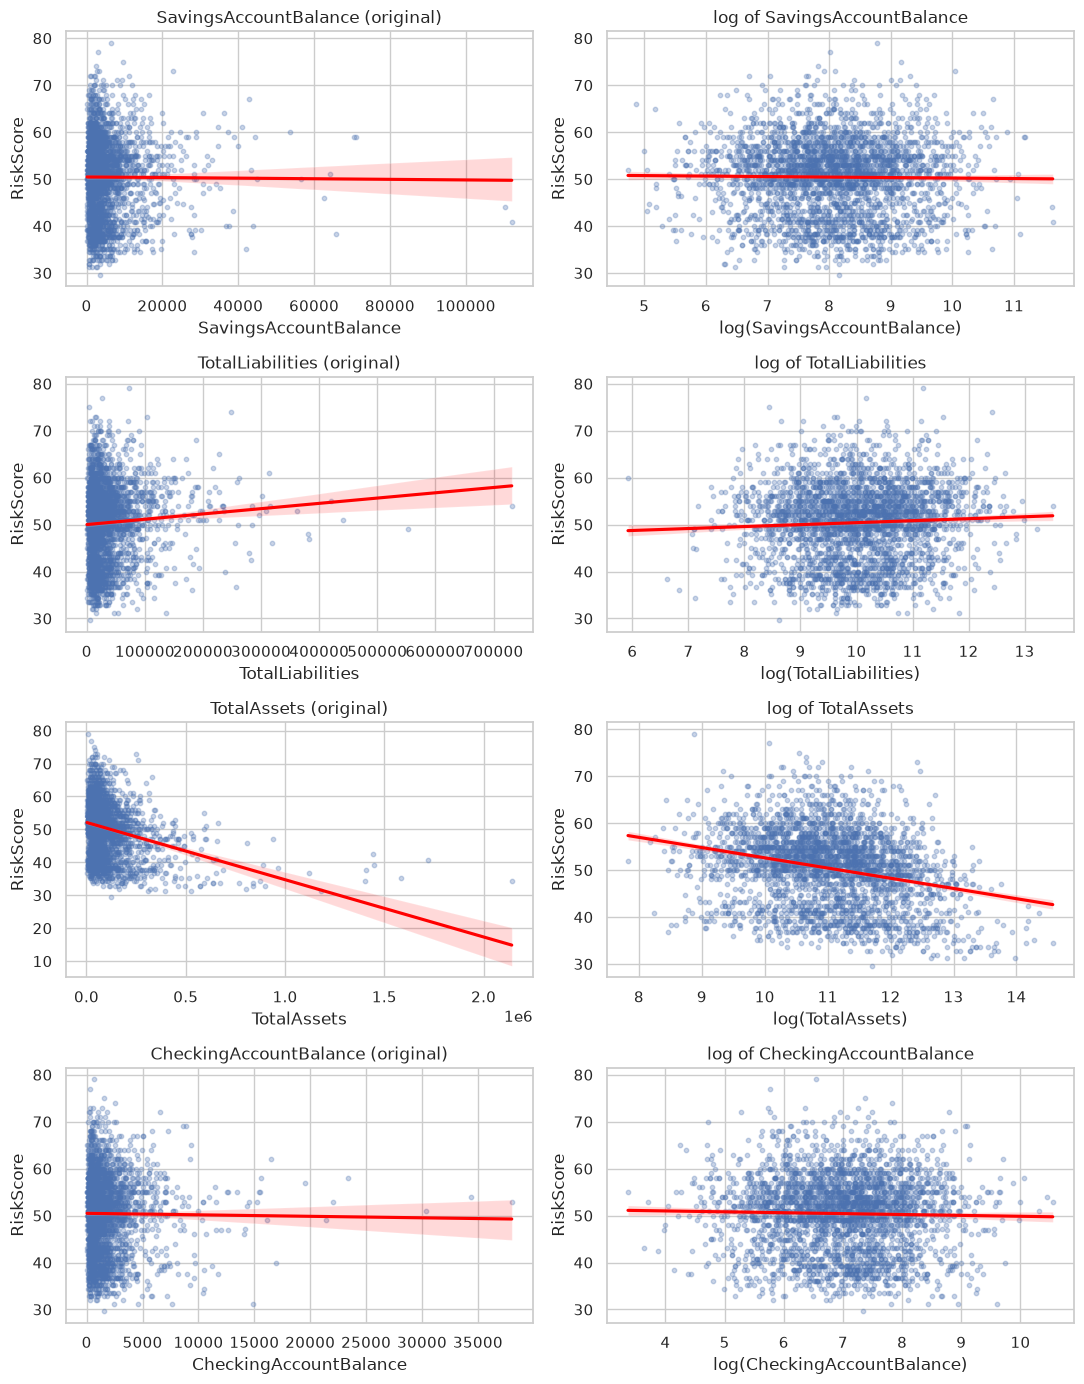

In [8]:
money = ["SavingsAccountBalance", "TotalLiabilities", "TotalAssets", "CheckingAccountBalance"]

fig, axes = plt.subplots(4, 2, figsize=(11, 14))
for row, c in zip(axes, money):
    # Left: original
    sns.regplot(data=sample, x=c, y="RiskScore",
                scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"}, ax=row[0])
    row[0].set_title(f"{c} (original)")

    # Right: log version
    sns.regplot(data=sample.assign(LogValue=np.log1p(sample[c])), x="LogValue", y="RiskScore",
                scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"}, ax=row[1])
    row[1].set_title(f"log of {c}")
    row[1].set_xlabel(f"log({c})")
plt.tight_layout(); plt.show()

In [9]:
feat = [c for c in num_cols if c != "RiskScore"]
r_original = df_labeled[feat].corrwith(df_labeled["RiskScore"])

log_cols = ["SavingsAccountBalance", "TotalLiabilities", "TotalAssets",
            "CheckingAccountBalance", "AnnualIncome", "LoanAmount"]
r_log = np.log1p(df_labeled[log_cols]).corrwith(df_labeled["RiskScore"])
r_log.index = ["log_" + c for c in r_log.index]

ranking = pd.concat([r_original, r_log]).rename("r")
ranking.reindex(ranking.abs().sort_values(ascending=False).index).round(2)

log_AnnualIncome             -0.48
AnnualIncome                 -0.48
BankruptcyHistory             0.38
DebtToIncomeRatio             0.33
TotalAssets                  -0.30
log_TotalAssets              -0.28
PreviousLoanDefaults          0.26
CreditScore                  -0.24
LengthOfCreditHistory        -0.18
Experience                   -0.17
Age                          -0.16
log_LoanAmount                0.15
LoanAmount                    0.14
CreditCardUtilizationRate     0.11
log_TotalLiabilities          0.06
TotalLiabilities              0.06
LoanDuration                  0.05
MonthlyDebtPayments           0.04
PaymentHistory               -0.02
NumberOfOpenCreditLines       0.01
log_SavingsAccountBalance    -0.01
UtilityBillsPaymentHistory   -0.01
JobTenure                    -0.00
CheckingAccountBalance       -0.00
NumberOfCreditInquiries       0.00
log_CheckingAccountBalance   -0.00
SavingsAccountBalance         0.00
NumberOfDependents            0.00
Name: r, dtype: floa

In [10]:
df_labeled[num_cols].skew().sort_values(ascending=False).head(8)

SavingsAccountBalance     6.060099
TotalLiabilities          5.848874
TotalAssets               5.311326
CheckingAccountBalance    4.746142
BankruptcyHistory         4.017672
PreviousLoanDefaults      2.665941
AnnualIncome              2.088948
LoanAmount                1.833688
dtype: float64

In [11]:
band = np.where(df_labeled["RiskScore"] < 45, "low band", "main band")
print(pd.Series(band).value_counts(normalize=True).round(2))   # share of each group

feat = [c for c in num_cols if c != "RiskScore"]
means = df_labeled.groupby(band)[feat].mean().T
means["gap_%"] = ((means["low band"] - means["main band"]) / means["main band"].abs() * 100).round(1)
means.sort_values("gap_%", key=abs, ascending=False).head(8)

main band    0.77
low band     0.23
Name: proportion, dtype: float64


,low band,main band,gap_%
AnnualIncome,99330.663740,47311.510425,110.0
BankruptcyHistory,0.001975,0.067275,-97.1
TotalAssets,146867.378183,82242.950984,78.6
PreviousLoanDefaults,0.045874,0.116032,-60.5
Experience,20.583845,16.619723,23.9
LoanAmount,20081.541484,26299.265281,-23.6
LengthOfCreditHistory,16.846356,14.400026,17.0
TotalLiabilities,33110.589552,37179.254662,-10.9


LoanApproved
0    54.1
1    40.1
Name: RiskScore, dtype: float64


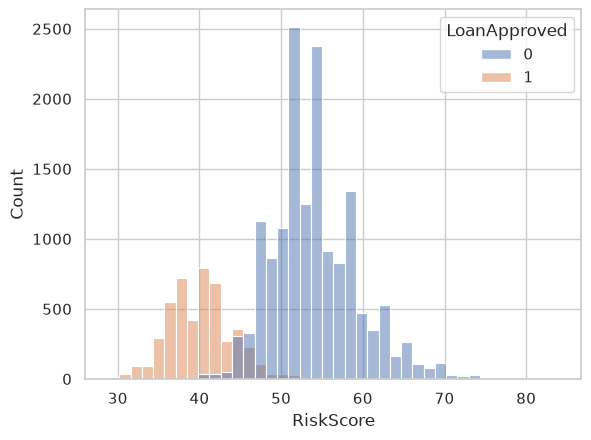

In [12]:
raw = pd.read_csv("../data/Loan.csv")
print(raw.groupby("LoanApproved")["RiskScore"].mean().round(1))

sns.histplot(data=raw, x="RiskScore", hue="LoanApproved", bins=40)
plt.show()

## Exercise 2: Numeric features vs. RiskScore

**Question:** Does each numeric feature have a straight-line link with `RiskScore`?

**Method:** Scatter plots with a fitted line on a random sample of 3,000 borrowers. For skewed money columns, I also plotted a log version. Skew was checked before and after the log. Nothing in the data files was changed.

### Findings

| Feature | Direction | Strength | Shape | Step 4 decision |
|---|---|---|---|---|
| `CreditScore` | Down | Loose | Fairly straight | Use as is |
| `DebtToIncomeRatio` | Up | Loose | Fairly straight | Use as is |
| `AnnualIncome` | Down | Strongest of the first four | Curved, one extreme earner distorts the line | **Log** |
| `LoanAmount` | Up | Weakest of the first four | Bunched left | **Log** (fairer line, small gain expected) |
| `TotalAssets` | Down | Clear | Bunched left | **Log** (most useful of the money columns) |
| `TotalLiabilities` | Up | Weak | Bunched left | **Log** |
| `SavingsAccountBalance` | None | None (flat line) | Bunched left | **Log**, expect little value |
| `CheckingAccountBalance` | None | None (flat line) | Bunched left | **Log**, expect little value |

### Skew before and after log

| Column | Before | After |
|---|---|---|
| `SavingsAccountBalance` | 6.06 | -0.01 |
| `TotalLiabilities` | 5.85 | -0.01 |
| `TotalAssets` | 5.31 | 0.04 |
| `CheckingAccountBalance` | 4.75 | -0.04 |
| `AnnualIncome` | 2.09 | 0.16 |
| `LoanAmount` | 1.83 | 0.02 |

The log fixes the skew for all six columns (all now between -1 and 1).

`BankruptcyHistory` (4.02) and `PreviousLoanDefaults` (2.67) also scored high on skew, but they are rare 0/1 flags, so a log does not apply.

### Conclusions

1. A straight line is a fair choice for `CreditScore` and `DebtToIncomeRatio`.
2. Six money columns have long right tails. Logging them spreads the dots evenly and makes the fitted line fairer.
3. `TotalAssets` and `AnnualIncome` show the clearest links. Savings and checking balances look flat, so I expect them to add little.
4. Every feature has a wide cloud around its line. No single feature predicts risk well alone, so the model will need many features together.
5. Two horizontal layers of risk scores appear across the charts (main group near 50 to 55, lower group near 35 to 45). This is explained below.

### Side finding: the two layers in RiskScore

- 77% of borrowers sit in the main group (RiskScore 45 and above). 23% sit in the low group (below 45).
- The low group has about double the income, 79% more assets, and far fewer bankruptcies and prior defaults.
- In the raw file, approved loans average a risk score of 40.1 vs. 54.1 for rejected loans, and the two groups barely overlap.
- This supports dropping `LoanApproved` as leakage in Step 2. I will describe the link as strong but not claim which one drives the other.


#### Categories and flags vs. RiskScore

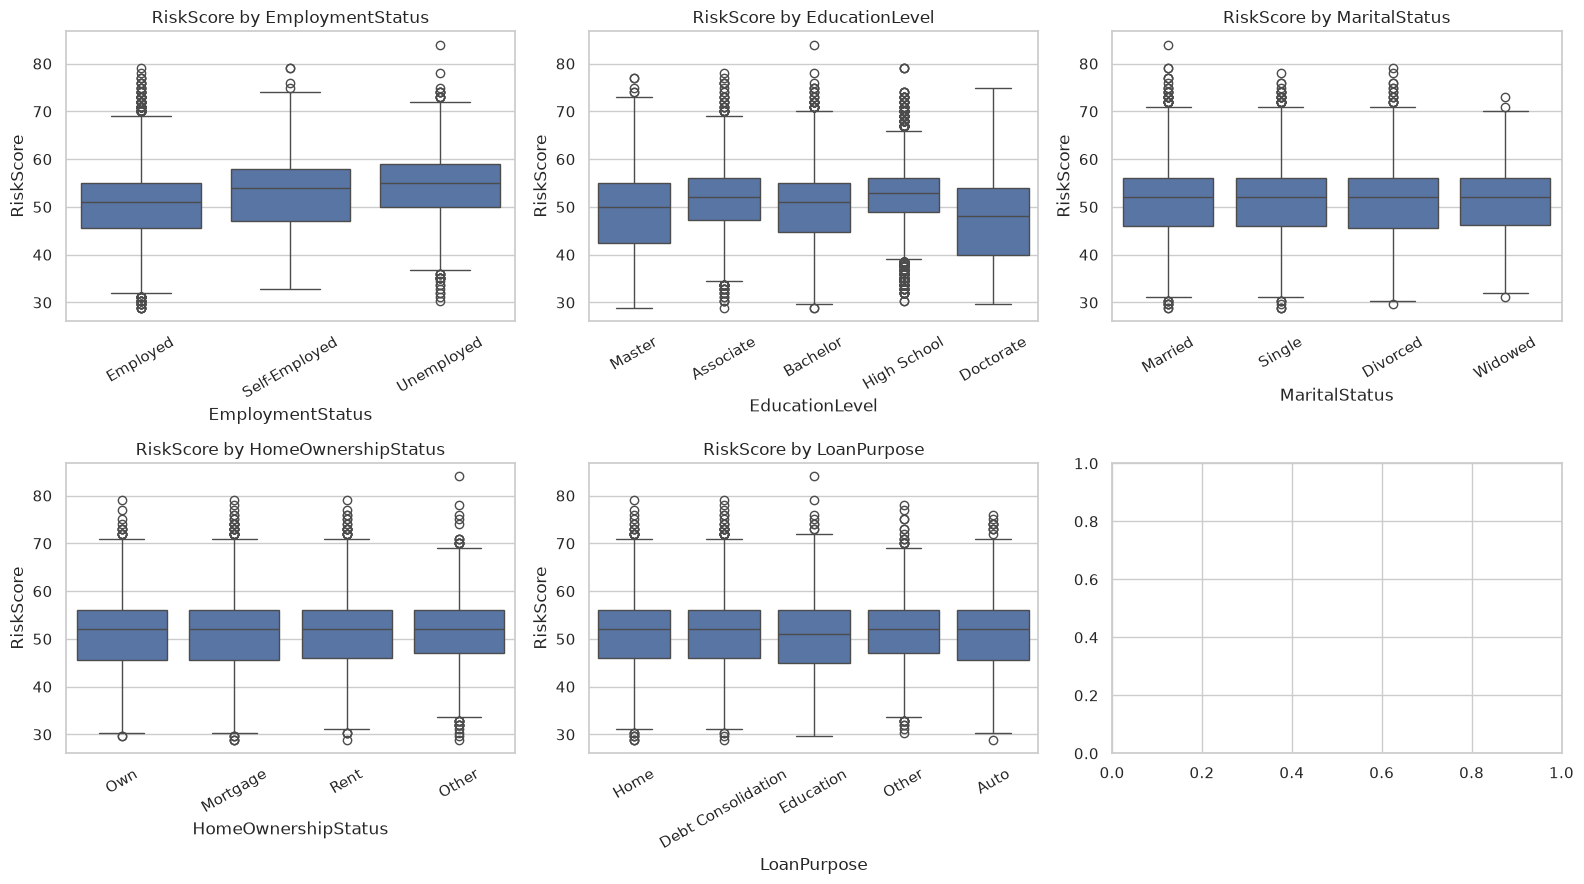

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.ravel(), cat_cols):
    sns.boxplot(data=df_labeled, x=c, y="RiskScore", ax=ax)
    ax.set_title(f"RiskScore by {c}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [14]:
for c in cat_cols:
    print(df_labeled.groupby(c)["RiskScore"].agg(["median", "mean", "count"]).round(1), "\n")

                  median  mean  count
EmploymentStatus                     
Employed            51.0  50.4  17036
Self-Employed       54.0  52.5   1573
Unemployed          55.0  53.9   1391 

                median  mean  count
EducationLevel                     
Associate         52.0  51.3   4034
Bachelor          51.0  50.3   6054
Doctorate         48.0  47.6    954
High School       53.0  52.2   5908
Master            50.0  49.1   3050 

               median  mean  count
MaritalStatus                     
Divorced         52.0  50.5   2882
Married          52.0  50.7  10041
Single           52.0  50.9   6078
Widowed          52.0  51.0    999 

                     median  mean  count
HomeOwnershipStatus                     
Mortgage               52.0  50.7   7939
Other                  52.0  51.1   2036
Own                    52.0  50.7   3938
Rent                   52.0  50.8   6087 

                    median  mean  count
LoanPurpose                            
Auto          

Compared RiskScore across the five categorical columns using box plots and group statistics. EmploymentStatus shows a clear order: Employed (mean 50.4), Self-Employed (52.5), Unemployed (53.9). EducationLevel shows a smaller order: Doctorate (47.6) lowest, High School (52.2) highest. MaritalStatus, HomeOwnershipStatus, and LoanPurpose differ by only about 0.5 points between groups, so they look uninformative. All groups have enough borrowers (smallest: Doctorate, 954). In Step 4 I expect the EmploymentStatus and EducationLevel dummies to matter and will check whether the other three can be dropped.

In [15]:
flags = [c for c in ["BankruptcyHistory", "PreviousLoanDefaults"] if c in df_labeled.columns]
for c in flags:
    print(df_labeled.groupby(c)["RiskScore"].agg(["mean", "count"]).round(2), "\n")

                    mean  count
BankruptcyHistory              
0                  50.08  18952
1                  63.26   1048 

                      mean  count
PreviousLoanDefaults             
0                     50.1  17999
1                     56.8   2001 



Borrowers with a bankruptcy history average a risk score of 63.3 vs 50.1 for those without, a gap of 13.2 points (1,048 borrowers, 5%). Borrowers with previous loan defaults average 56.8 vs 50.1, a gap of 6.7 points (2,001 borrowers, 10%). These are the largest group effects found in the categorical comparisons, far above EmploymentStatus (3.5) and EducationLevel (4.6). Both flags are rare, so they affect few borrowers, and each comparison ignores other features. I expect both to carry large coefficients in Step

## Exercise 3: Categories and flags vs. RiskScore

**Question:** Does the group a borrower belongs to shift their risk score?

**Method:**
- **Part A:** box plots and group statistics (median, mean, count) of `RiskScore` for the 5 text columns.
- **Part B:** average `RiskScore` for borrowers with and without each 0/1 flag.

### Part A: Text columns

| Column | Lowest group (mean) | Highest group (mean) | Gap | Verdict |
|---|---|---|---|---|
| `EducationLevel` | Doctorate (47.6) | High School (52.2) | 4.6 | Small but real effect |
| `EmploymentStatus` | Employed (50.4) | Unemployed (53.9) | 3.5 | Clear effect |
| `LoanPurpose` | Education (50.5) | Other (51.1) | 0.6 | No effect |
| `MaritalStatus` | Divorced (50.5) | Widowed (51.0) | 0.5 | No effect |
| `HomeOwnershipStatus` | Mortgage / Own (50.7) | Other (51.1) | 0.4 | No effect |

**Order of groups**
- `EmploymentStatus`: Employed (50.4) < Self-Employed (52.5) < Unemployed (53.9).
- `EducationLevel`: Doctorate (47.6) < Master (49.1) < Bachelor (50.3) < Associate (51.3) < High School (52.2). More education goes with lower risk.

**Group sizes:** all groups are large enough to trust. The smallest is Doctorate with 954 borrowers (about 5%). 85% of borrowers are `Employed`, so the other two employment groups cover only about 15% of the data.

### Part B: 0/1 flags

| Flag | Without (0) | With (1) | Gap | Borrowers with the flag |
|---|---|---|---|---|
| `BankruptcyHistory` | 50.08 | 63.26 | **13.2** | 1,048 (5%) |
| `PreviousLoanDefaults` | 50.1 | 56.8 | **6.7** | 2,001 (10%) |

### Ranking of group effects

| Rank | Feature | Gap in average risk |
|---|---|---|
| 1 | `BankruptcyHistory` | 13.2 |
| 2 | `PreviousLoanDefaults` | 6.7 |
| 3 | `EducationLevel` | 4.6 |
| 4 | `EmploymentStatus` | 3.5 |
| 5 to 7 | `LoanPurpose`, `MaritalStatus`, `HomeOwnershipStatus` | about 0.5 (flat) |

### Conclusions

1. `BankruptcyHistory` is the strongest group effect, about 3 times larger than any text column.
2. `PreviousLoanDefaults` is second. Worse credit history goes with higher risk, as expected.
3. `EmploymentStatus` and `EducationLevel` have small but clear effects.
4. `LoanPurpose`, `MaritalStatus`, and `HomeOwnershipStatus` look uninformative: their groups differ by only about 0.5 points.
5. The two flags are rare (5% and 10%), so they matter a lot for the borrowers they affect but cannot explain `RiskScore` alone.
6. This matches the two-layers finding in Exercise 2: the low-risk group had 97% fewer bankruptcies and 61% fewer prior defaults.

### Cautions

- Each comparison looks at **one column at a time** and ignores other features. For example, borrowers with a bankruptcy may also have lower income, so part of the 13-point gap may belong to other features. Step 4 separates these.
- Even the biggest gap is small next to the full `RiskScore` range (about 30 to 80).

## Correlation and overlap

AnnualIncome                 -0.483289
TotalAssets                  -0.297117
CreditScore                  -0.240198
LengthOfCreditHistory        -0.177796
Experience                   -0.166496
Age                          -0.164304
PaymentHistory               -0.016992
UtilityBillsPaymentHistory   -0.005196
JobTenure                    -0.004393
CheckingAccountBalance       -0.004044
NumberOfDependents            0.001686
SavingsAccountBalance         0.002190
NumberOfCreditInquiries       0.003103
NumberOfOpenCreditLines       0.007762
MonthlyDebtPayments           0.036938
LoanDuration                  0.054550
TotalLiabilities              0.055617
CreditCardUtilizationRate     0.108758
LoanAmount                    0.137981
PreviousLoanDefaults          0.258659
DebtToIncomeRatio             0.326500
BankruptcyHistory             0.377578
Name: RiskScore, dtype: float64


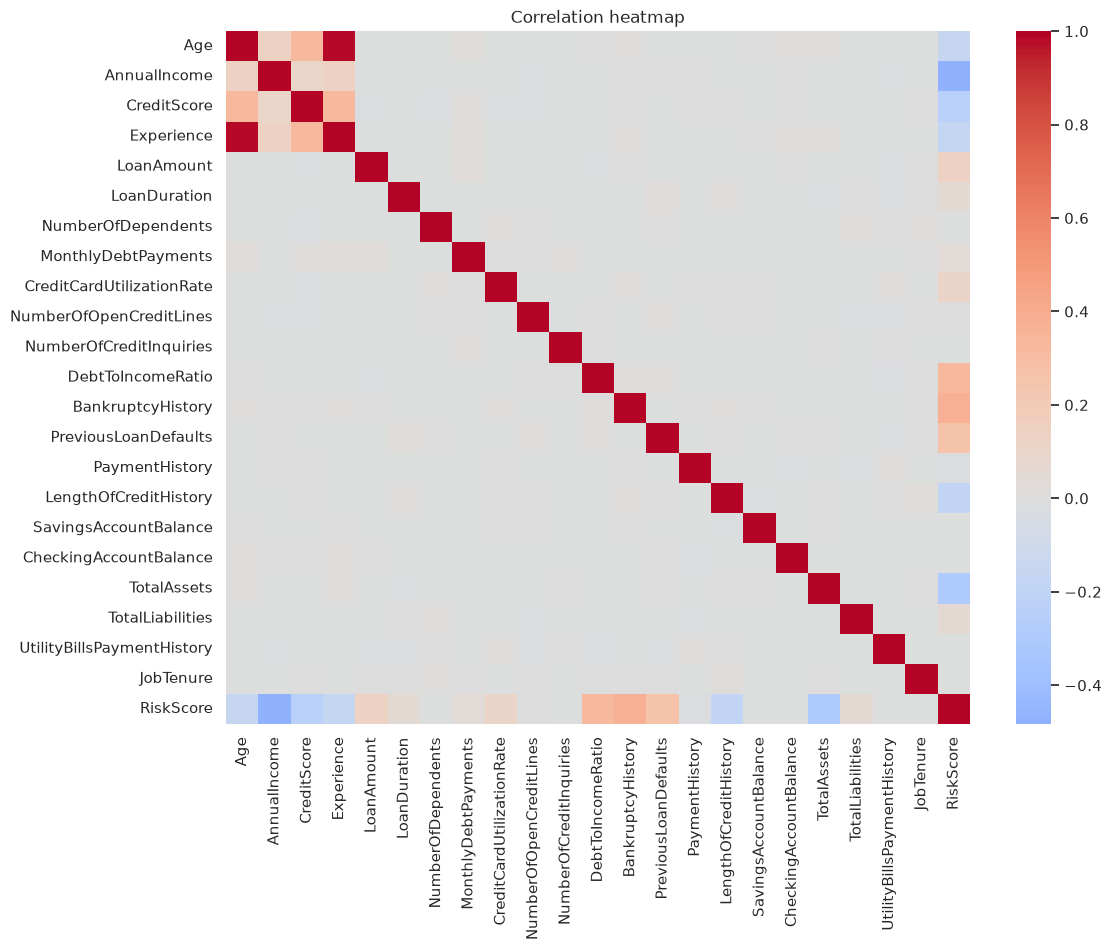

Age  Experience    0.98298
dtype: float64


In [16]:
corr = df_labeled[num_cols].corr()

# 1) Which features link most to RiskScore?
print(corr["RiskScore"].drop("RiskScore").sort_values())

# 2) Heatmap of everything
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

# 3) Feature pairs that overlap (|r| > 0.7)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(upper[upper.abs() > 0.7].sort_values(key=abs, ascending=False))

In [17]:
print(ranking.reindex(ranking.abs().sort_values(ascending=False).index).round(2).to_string())

log_AnnualIncome             -0.48
AnnualIncome                 -0.48
BankruptcyHistory             0.38
DebtToIncomeRatio             0.33
TotalAssets                  -0.30
log_TotalAssets              -0.28
PreviousLoanDefaults          0.26
CreditScore                  -0.24
LengthOfCreditHistory        -0.18
Experience                   -0.17
Age                          -0.16
log_LoanAmount                0.15
LoanAmount                    0.14
CreditCardUtilizationRate     0.11
log_TotalLiabilities          0.06
TotalLiabilities              0.06
LoanDuration                  0.05
MonthlyDebtPayments           0.04
PaymentHistory               -0.02
NumberOfOpenCreditLines       0.01
log_SavingsAccountBalance    -0.01
UtilityBillsPaymentHistory   -0.01
JobTenure                    -0.00
CheckingAccountBalance       -0.00
NumberOfCreditInquiries       0.00
log_CheckingAccountBalance   -0.00
SavingsAccountBalance         0.00
NumberOfDependents            0.00


In [18]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(upper[upper.abs() > 0.7].sort_values(key=abs, ascending=False))

Age  Experience    0.98298
dtype: float64


## Exercise 4: Correlation and overlap

**Questions:**
1. Which numeric features link most strongly to `RiskScore`?
2. Which features repeat each other?

**Method:** Pearson correlation (r) of every numeric feature with `RiskScore`, including log versions of the 6 skewed money columns. A heatmap of all numeric features. A list of feature pairs with |r| above 0.7.

**Why 0.7?** It is a common rule-of-thumb cutoff, not a law. Many textbooks call |r| of 0.7 or more "strongly correlated", and 0.7 to 0.8 is a typical screening line for near-duplicate features. It is a quick first filter. The formal check is VIF in Step 4. Judging by the heatmap, the next-strongest pairs were far below 0.7, so a cutoff anywhere from 0.5 to 0.9 gives the same list here.

**How to read r:** the sign is the direction (positive = same way, negative = opposite ways). The size, |r|, is the strength: below 0.1 negligible, 0.1 to 0.3 weak, 0.3 to 0.5 moderate, above 0.5 strong.

### Ranking of features by link to RiskScore

| Tier | Feature | r | Meaning |
|---|---|---|---|
| **Moderate** | `AnnualIncome` | -0.48 | Higher income, lower risk. **Strongest feature.** |
| | `BankruptcyHistory` | +0.38 | Bankruptcy, higher risk |
| | `DebtToIncomeRatio` | +0.33 | More debt vs. income, higher risk |
| | `TotalAssets` | -0.30 | More assets, lower risk |
| **Weak** | `PreviousLoanDefaults` | +0.26 | Prior defaults, higher risk |
| | `CreditScore` | -0.24 | Higher score, lower risk |
| | `LengthOfCreditHistory` | -0.18 | Longer history, lower risk |
| | `Experience` | -0.17 | More experience, lower risk |
| | `Age` | -0.16 | Older, lower risk |
| | `LoanAmount` | +0.14 | Bigger loan, higher risk |
| | `CreditCardUtilizationRate` | +0.11 | Higher use, higher risk |
| **Negligible** | `TotalLiabilities` (0.06), `LoanDuration` (0.05), `MonthlyDebtPayments` (0.04), `PaymentHistory` (-0.02), `NumberOfOpenCreditLines` (0.01), `UtilityBillsPaymentHistory` (-0.01), `JobTenure` (0.00), `CheckingAccountBalance` (0.00), `NumberOfCreditInquiries` (0.00), `SavingsAccountBalance` (0.00), `NumberOfDependents` (0.00) | -0.02 to +0.06 | No straight-line link |

### Original vs. log

| Feature | Original r | Log r |
|---|---|---|
| `AnnualIncome` | -0.48 | -0.48 |
| `TotalAssets` | -0.30 | -0.28 |
| `LoanAmount` | +0.14 | +0.15 |
| `TotalLiabilities` | +0.06 | +0.06 |
| `SavingsAccountBalance` | 0.00 | -0.01 |
| `CheckingAccountBalance` | 0.00 | 0.00 |

The log fixed the **shape** (skew near 0) but did not strengthen the link. I do not expect a large R² gain from it.

### Overlapping features (|r| > 0.7)

Only one pair:

| Pair | r |
|---|---|
| `Age` and `Experience` | 0.98 |

They carry almost the same information. No other pair is above 0.7, so the money columns do not overlap.

### Heatmap reading

- Bottom row (`RiskScore`): darkest blue is `AnnualIncome`, darkest orange is `BankruptcyHistory`.
- Rest of the grid: almost all light grey (no links between features). The only dark red square off the diagonal is `Age` and `Experience`.

### Conclusions

1. No single feature is strong. The best, `AnnualIncome`, reaches |r| = 0.48, so the model must combine many features.
2. Four features lead: `AnnualIncome`, `BankruptcyHistory`, `DebtToIncomeRatio`, `TotalAssets`.
3. About 11 numeric features are near zero and should add little.
4. `PaymentHistory` has essentially no link (r = -0.02), so its direction is not meaningful.
5. Correlation only measures **straight-line** links. A near-zero r does not prove "no link", so I will confirm in Step 4 using model coefficients.
6. The only overlap problem is `Age` and `Experience`.

## Key Insights from EDA

##### Insight 1: Income and credit score
Higher credit scores go with lower risk scores (r = -0.24), but the link is weak. Annual income is stronger (r = -0.48) and is the strongest numeric link in the data. Both fall short of "strong" (|r| above 0.5), so no single feature predicts risk well alone. I will keep both and expect income to matter more.

##### Insight 2: Bankruptcy history
Borrowers with a bankruptcy history average a risk score of 63.3, vs. 50.1 for those without, a gap of 13.2 points. This is the largest group effect in the data, about 3 times bigger than any text column. Only 1,048 borrowers (5%) have a bankruptcy on record, so the flag matters a lot for a few people but cannot explain risk on its own. This compares one feature at a time, so part of the gap may belong to other features, such as lower income. I will keep it and let the Step 4 coefficients separate its effect.

##### Insight 3: Overlapping features
Age and Experience overlap almost completely (r = 0.98), so they carry nearly the same information. No other pair is above 0.7, so the rest of the features are not repeating each other. In Step 4 I will keep one of the two (their links to risk are nearly identical, -0.16 and -0.17) and confirm with VIF that no overlap remains.

##### Insight 4 (optional): Skewed money columns
Six money columns have long right tails (skew from 1.83 to 6.06). A log transform brought all of them close to 0 (between -0.04 and 0.16) and spread the dots evenly in the scatter plots. It did not strengthen their link to risk (for example AnnualIncome stayed at r = -0.48). I will compare R² with and without the log in Step 4 and expect only a small difference.